## I-JEPA Forward Pass

Load an image, mask it, run the encoder + predictor, compute the loss

In [1]:
import jax
from jax import numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt

from jepax.data import build_torch_dataloader
from jepax.model.masker import IJEPAMasker, visualize_mask
from jepax.model.ijepa import get_ijepa_model

In [ ]:
PATCH_SIZE = 2
IMG_SIZE = 32
N_PATCH = IMG_SIZE // PATCH_SIZE  # 16
M = 4  # number of prediction masks

key = jax.random.PRNGKey(42)

## 1. Load data & visualize masks

Load a single data point. Visualize the encoder mask by constructing it with context and predictor mask from the masker.



In [20]:
dataloader, _, _, _ = build_torch_dataloader("CIFAR10", data_dir="~/data")

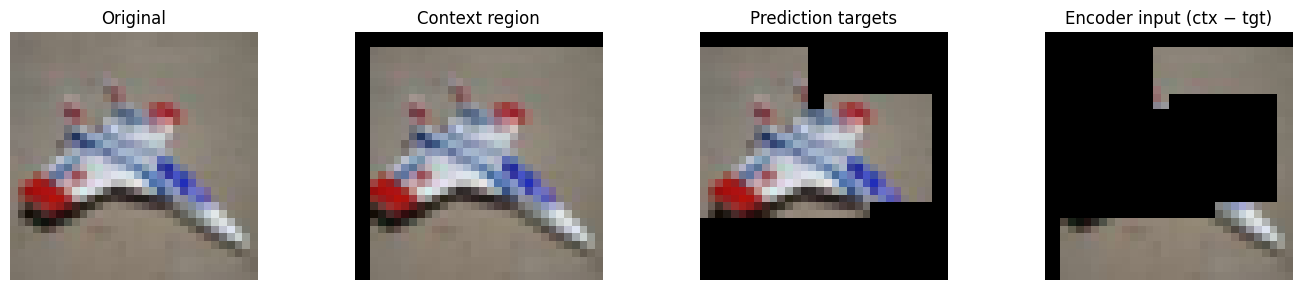

In [21]:
x, y = next(iter(dataloader))
x_in = x[-2]

masker = IJEPAMasker(
    IMG_SIZE, IMG_SIZE, PATCH_SIZE,
    ctx_scale=0.85,
    pred_scale=(0.15, 0.2),
    pred_aspect=(0.75, 1.2),
)

key, key_mask = jax.random.split(key)
mask_ctx, mask_pred = masker(key_mask, M, flatten=True)

# what the encoder sees
mask_pred_union = jnp.any(mask_pred, axis=0)
mask_enc = mask_ctx & ~mask_pred_union

show = lambda img, mask: visualize_mask(img, mask, PATCH_SIZE, N_PATCH)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(x_in)
axes[0].set_title("Original")
axes[1].imshow(show(x_in, mask_ctx))
axes[1].set_title("Context region")
axes[2].imshow(show(x_in, mask_pred_union))
axes[2].set_title("Prediction targets")
axes[3].imshow(show(x_in, mask_enc))
axes[3].set_title("Encoder input (ctx − tgt)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Build model & forward pass

In [22]:
x_in = jnp.transpose(x[0], (2, 0, 1))

In [28]:
key, key_model = jax.random.split(key)

model, embed_dim = get_ijepa_model(
    "ijepa-test",
    key=key_model,
    num_channels=3,
    patch_size=PATCH_SIZE,
    img_size=IMG_SIZE,
    p_drop=0.0,
)

print(f"Embed dim: {embed_dim}")
print(f"Encoder blocks: {len(model.encoder.transformer.blocks)}")
print(f"Predictor blocks: {len(model.predictor.transformer.blocks)}")
n_params = sum(x.size for x in jax.tree.leaves(eqx.filter(model, eqx.is_array)))
print(f"Total params: {n_params:,}")

Embed dim: 64
Encoder blocks: 2
Predictor blocks: 2
Total params: 89,152


In [29]:
# Forward pass through the full model
key, key_fwd = jax.random.split(key)

z_pred, tgt_indices, n_tgt, pred_start, pred_end = model(
    key_fwd, x_in, mask_ctx, mask_pred, train=False
)

print(f"z_pred: {z_pred.shape} (seq_len, D)")
print(f"n_tgt: {n_tgt}")

z_pred: (256, 64) (seq_len, D)
n_tgt: 136


## 3. Compute I-JEPA loss

Though the paper uses $L_2$ loss among target patches, training involves the `torch` smooth $L_1$ loss, defined as
$$
    \ell_\beta(x) = \begin{cases}
        \| x\|_1 & \, \| x\|_1 \geq \beta \\
        \| x\|_2^2 & \, \text{else} \\
    \end{cases}
$$
That is, the gradient at each parameter is clipped to $\pm \beta$. In the IJEPA implementation, $\beta = 1$. In the 1D case
$$
    \frac{d\ell_\beta}{dx}(x) = \begin{cases}
        \beta \cdot \text{sgn}(x) & \, \| x\|_1 \geq \beta \\
        x & \, \text{else} \\
    \end{cases}
$$
More on this in the blog..

In [30]:
# EMA target: encode full image 
key, key_ema = jax.random.split(key)
ema_encoder = model.encoder  # typically the ema copy

z_ema, _, _ = eqx.nn.inference_mode(ema_encoder)(key_ema, x_in, mask=None, train=False)
print(f"z_ema (full image): {z_ema.shape}")  # (N_patches, D)

# Optional: normalize targets
mean = jnp.mean(z_ema, axis=-1, keepdims=True)
var = jnp.var(z_ema, axis=-1, keepdims=True)
z_ema = (z_ema - mean) / jnp.sqrt(var + 1e-6)

z_ema (full image): (256, 64)


In [31]:
# Extract target representations at predicted positions
z_tgt = z_ema[tgt_indices]  # (seq_len, D)

# Shift predictor output to align: predictions sit at [pred_start:pred_end]
z_pred_shifted = jnp.roll(z_pred, -pred_start, axis=0)

# Valid mask: only the first n_tgt positions matter
valid = jnp.arange(z_pred.shape[0]) < n_tgt

# Smooth L1 loss 
diff = z_pred_shifted - z_tgt
abs_diff = jnp.abs(diff)
smooth_l1 = jnp.where(abs_diff < 1.0, 0.5 * diff**2, abs_diff - 0.5)

loss_per_token = jnp.mean(smooth_l1, axis=-1)  # (seq_len,)
loss = jnp.sum(loss_per_token * valid) / jnp.sum(valid)

print(f"Smooth L1 loss: {loss:.4f}")
print(f"Valid target tokens: {int(jnp.sum(valid))} / {z_pred.shape[0]}")

Smooth L1 loss: 0.5264
Valid target tokens: 136 / 256
